# Offline PDA: P-case

In [1]:
import os
os.chdir('/glade/work/fengzhu/Projects/paper-OnlinePDA_CESM/notebooks')
import numpy as np
import pandas as pd
import x4c
import cfr
cfr.use('v2026')
import datetime
print(f'Last update: {datetime.date.today()}')

octave not found, please see README
Last update: 2026-06-18


## Obs Setup

In [2]:
da_truth = x4c.open_dataset('../prior/ppe_Plio400ppm_ann.nc')['TEMP'].isel(z_t=0).mean('time')
da_truth

<xarray.DataArray 'TEMP' (nlat: 394, nlon: 320)> Size: 504kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(394, 320), dtype=float32)
Coordinates:
    TLAT     (nlat, nlon) float64 1MB ...
    TLONG    (nlat, nlon) float64 1MB ...
    ULAT     (nlat, nlon) float64 1MB ...
    ULONG    (nlat, nlon) float64 1MB ...
    z_t      float32 4B 500.0
Dimensions without coordinates: nlat, nlon
Attributes:
    long_name:     Potential Temperature (Annual)
    units:         °C
    grid_loc:      3111
    cell_methods:  time: mean
    path:          ['/glade/campaign/univ/uazn0034/fengzhu/CESM_output/timese...
    comp:          ocn
    grid:          g16

In [3]:
R = 0.01
df = pd.read_json(f'../pseudoproxy/ppe_Plio400ppm_obs_SST_R{R:.2f}.json')
obs = cfr.Obs(df)
obs.setup()
obs.df

,pid,lat,lon,time,value,R,type,psm_name
0,DSDP516.Mg/Ca,-30.646322,324.994450,[3.5],[23.1653251648],0.01,T,IdenticalSST
1,DSDP552.Mg/Ca,55.593510,345.982189,[3.5],[17.0483608246],0.01,T,IdenticalSST
2,DSDP590.Mg/Ca,-32.594207,162.898037,[3.5],[22.5412883759],0.01,T,IdenticalSST
3,DSDP603.Mg/Ca,35.261855,290.479297,[3.5],[25.1493167877],0.01,T,IdenticalSST
4,DSDP609.Mg/Ca,49.422589,335.045676,[3.5],[16.7079963684],0.01,T,IdenticalSST
...,...,...,...,...,...,...,...,...
103,ODP959.UK37,3.053953,356.530460,[3.5],[29.6693210602],0.01,T,IdenticalSST
104,ODP978.UK37,35.655501,357.297471,[3.5],[23.1417293549],0.01,T,IdenticalSST
105,ODP982.UK37,57.058493,343.381278,[3.5],[16.6606521606],0.01,T,IdenticalSST
106,ODP999.UK37,12.533555,281.067292,[3.5],[28.507900238],0.01,T,IdenticalSST


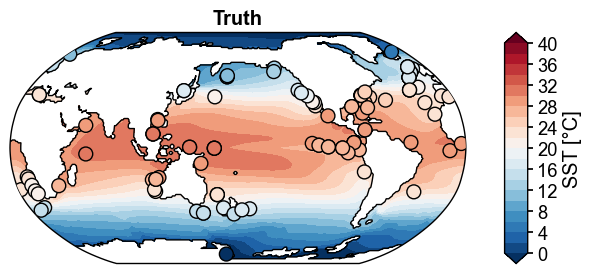

In [4]:
x4c.set_style('journal', font_scale=1.2)
fig, ax = obs.plot(
    levels=np.linspace(0, 40, 21),
    cbar_kwargs={'ticks': np.linspace(0, 40, 11), 'label': 'SST [°C]'},
    cyclic=True,
    da_target=da_truth.x.regrid(),
    title='Truth',
)
x4c.showfig(fig)

## Prior Setup

In [5]:
pm = []
case_list = ['1xCO2', '350ppm', '490ppm', '2xCO2']
for tag in case_list:
    ds = x4c.open_dataset(f'../prior/ppe_Plio{tag}_ann.nc')
    ds['PSL'] /= 100
    ds['PSL'].attrs['units'] = 'hPa'
    pm.append(cfr.PriorMember(ds.mean('time')))

prior = cfr.Prior(pm)
prior.ds['ens'] = ('ens', case_list)
prior.ds

<xarray.Dataset> Size: 13MB
Dimensions:  (ncol: 48602, ens: 4, z_t: 1, nlat: 394, nlon: 320)
Coordinates:
    lat      (ncol) float64 389kB -35.26 -35.65 -36.26 ... 36.68 36.68 36.05
    lon      (ncol) float64 389kB 315.0 315.8 317.2 318.0 ... 133.7 136.3 135.0
  * ens      (ens) <U6 96B '1xCO2' '350ppm' '490ppm' '2xCO2'
  * z_t      (z_t) float32 4B 500.0
    TLAT     (nlat, nlon) float64 1MB -84.56 -84.56 -84.56 ... 72.2 72.19 72.19
    TLONG    (nlat, nlon) float64 1MB 320.6 321.7 322.8 ... 318.9 319.4 319.8
    ULAT     (nlat, nlon) float64 1MB -84.3 -84.3 -84.3 ... 72.42 72.41 72.41
    ULONG    (nlat, nlon) float64 1MB 321.1 322.3 323.4 ... 319.2 319.6 320.0
Dimensions without coordinates: ncol, nlat, nlon
Data variables:
    PRECT    (ncol, ens) float32 778kB 4.023e-08 4.183e-08 ... 6.469e-08
    PSL      (ncol, ens) float32 778kB 1.018e+03 1.018e+03 ... 1.017e+03
    SALT     (z_t, nlat, nlon, ens) float32 2MB nan nan nan nan ... nan nan nan
    TEMP     (z_t, nlat, nlon, ens) float32 2MB nan nan nan nan ... nan nan nan
    TS       (ncol, ens) float32 778kB 19.5 20.37 21.39 ... 19.82 20.87 21.65
    aice     (nlat, nlon, ens) float32 2MB nan nan nan nan ... nan nan nan nan
Attributes:
    history:  Thu Jun 18 11:06:47 2026: ncks -O -d z_t,0,0 -4 -L 4 ppe_Plio1x...
    NCO:      netCDF Operators version 5.3.4 (Homepage = http://nco.sf.net, C...
    path:     /glade/work/fengzhu/Projects/paper-OnlinePDA_CESM/prior/ppe_Pli...
    gw:       <xarray.DataArray 'lat' (ncol: 48602)> Size: 389kB\narray([0.81...

In [6]:
prior.set_hcoords({
    'TS': ('lat', 'lon'),
    'PRECT': ('lat', 'lon'),
    'PSL': ('lat', 'lon'),
    'TEMP': ('TLAT', 'TLONG'),
    'SALT': ('TLAT', 'TLONG'),
    'aice': ('TLAT', 'TLONG'),
})

## Run the EnKF Solver

In [7]:
da_solver = cfr.enkf.Solver(prior, obs)

da_solver.prep(
    loc_radius=10000, # localization radius, i.e., half of the cutoff radius
    loc_method='gaspari_cohn',
    startover=True,
    get_clim_kws={
        'lat_coord': 'TLAT',
        'lon_coord': 'TLONG',
        'lat_dim': 'nlat',
        'lon_dim': 'nlon',
    },
)

>>> Proxy System Modeling: Y = H(X)
>>> Computing the localization matrix


Processing variables: 100%|██████████| 6/6 [00:03<00:00,  1.63it/s]


In [8]:
da_solver.run(
    method='EnSRF',
)

>>> DA update


Updating time slices: 100%|██████████| 1/1 [00:00<00:00,  1.44it/s]


In [9]:
da_solver.post.to_netcdf(f'../recons/recon_Plio400ppm_R{R:.2f}_loc10000.nc')
da_solver.post

<xarray.Dataset> Size: 22MB
Dimensions:  (time: 1, ncol: 48602, ens: 4, z_t: 1, nlat: 394, nlon: 320)
Coordinates:
  * time     (time) float64 8B 3.5
    lat      (ncol) float64 389kB -35.26 -35.65 -36.26 ... 36.68 36.68 36.05
    lon      (ncol) float64 389kB 315.0 315.8 317.2 318.0 ... 133.7 136.3 135.0
  * ens      (ens) <U6 96B '1xCO2' '350ppm' '490ppm' '2xCO2'
  * z_t      (z_t) float32 4B 500.0
    TLAT     (nlat, nlon) float64 1MB -84.56 -84.56 -84.56 ... 72.2 72.19 72.19
    TLONG    (nlat, nlon) float64 1MB 320.6 321.7 322.8 ... 318.9 319.4 319.8
    ULAT     (nlat, nlon) float64 1MB -84.3 -84.3 -84.3 ... 72.42 72.41 72.41
    ULONG    (nlat, nlon) float64 1MB 321.1 322.3 323.4 ... 319.2 319.6 320.0
Dimensions without coordinates: ncol, nlat, nlon
Data variables:
    PRECT    (time, ncol, ens) float64 2MB 4.227e-08 4.238e-08 ... 6.191e-08
    PSL      (time, ncol, ens) float64 2MB 1.018e+03 1.018e+03 ... 1.017e+03
    SALT     (time, z_t, nlat, nlon, ens) float64 4MB nan nan nan ... nan nan
    TEMP     (time, z_t, nlat, nlon, ens) float64 4MB nan nan nan ... nan nan
    TS       (time, ncol, ens) float64 2MB 20.83 20.84 20.86 ... 20.2 20.25
    aice     (time, nlat, nlon, ens) float64 4MB nan nan nan nan ... nan nan nan